# 03 — Addestramento dei modelli

Addestra e confronta i modelli per la stima dello State of Health:

- baseline di persistenza;
- MLP;
- SimpleRNN;
- LSTM;
- GRU.

Il dataset sequenziale è quello prodotto da `02_sequence_preparation.ipynb`.

Ogni modello viene addestrato più volte con inizializzazioni diverse. Ripetere serve a
capire se una differenza fra due modelli sia reale o dipenda solo da come sono stati
inizializzati i pesi.

**Notebook successivo:** `04_data_scaling_experiment.ipynb`.


## 1. Configurazione


In [1]:
import json
import os
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass


def find_project_root():
    """Individua la cartella di progetto, in locale o su Google Drive."""
    candidate_paths = []
    current_path = Path.cwd().resolve()
    candidate_paths.extend([current_path] + list(current_path.parents))
    candidate_paths.extend([
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/SoH_Neural_Tracker"),
    ])

    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"

for folder in [EXPERIMENTS_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("Radice del progetto:", PROJECT_ROOT)
print("TensorFlow:", tf.__version__)
print("GPU disponibili:", len(tf.config.list_physical_devices("GPU")))


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker
TensorFlow: 2.20.0
GPU disponibili: 0


## 2. Caricamento del dataset sequenziale

Ogni ingresso `X` ha forma *(numero di finestre, cicli per finestra, variabili)*. Il
target `y` è lo State of Health del ciclo successivo alla finestra.

Viene caricato anche `soh_ultimo`, il SoH dell'ultimo ciclo osservato di ogni finestra:
serve alla baseline.


In [2]:
# Il notebook 02 salva ogni versione del dataset in una sottocartella propria.
CONFIGURAZIONE = "scarica"
disponibili = sorted(DATA_PROCESSED.glob(f"sequences_{CONFIGURAZIONE}/*.npz"))
assert disponibili, (
    f"nessun dataset in data/processed/sequences_{CONFIGURAZIONE}/: "
    "esegui prima 02_sequence_preparation.ipynb"
)

percorso_dati = disponibili[0]
archivio = np.load(percorso_dati, allow_pickle=True)

INSIEMI = ["train", "validation", "test_id", "test_ood"]

X = {nome: archivio[f"{nome}__X"] for nome in INSIEMI}
y = {nome: archivio[f"{nome}__y"] for nome in INSIEMI}
soh_ultimo = {nome: archivio[f"{nome}__soh_ultimo"] for nome in INSIEMI}
batteria = {nome: archivio[f"{nome}__battery_id"] for nome in INSIEMI}
ciclo = {nome: archivio[f"{nome}__target_cycle"] for nome in INSIEMI}

FEATURE_NAMES = list(archivio["feature_names"])
WINDOW_SIZE = int(archivio["window_size"])

print("Dataset:", percorso_dati.name)
print(f"Finestra: {WINDOW_SIZE} cicli   variabili: {len(FEATURE_NAMES)}\n")
blocco = {nome: archivio[f"{nome}__protocol_block"] for nome in INSIEMI}
for nome in INSIEMI:
    print(f"{nome:12s} X {str(X[nome].shape):18s} y {str(y[nome].shape):8s} "
          f"blocchi: {', '.join(sorted(set(blocco[nome])))}")


Dataset: sequence_dataset_window10.npz
Finestra: 10 cicli   variabili: 10

train        X (316, 10, 10)      y (316,)   blocchi: B0005_p1, B0006_p1
validation   X (158, 10, 10)      y (158,)   blocchi: B0007_p1
test_id      X (172, 10, 10)      y (172,)   blocchi: B0018_p1, B0042_p1, B0043_p1
test_ood     X (150, 10, 10)      y (150,)   blocchi: B0029_p1, B0030_p1, B0031_p1, B0032_p1, B0042_p2, B0043_p2


## 3. La grandezza che il modello prevede

Il modello non produce direttamente lo State of Health, ma **di quanto cambia** da un
ciclo al successivo. La stima finale è l'ultimo valore osservato più la variazione
prevista:

$$\widehat{\mathrm{SoH}}(t+1) = \mathrm{SoH}(t) + \widehat{\Delta}$$

È la stessa quantità, riscritta. Il motivo del cambio è che le due scritture pongono al
modello un compito di difficoltà molto diversa.

Lo State of Health vale fra 0.6 e 1 e cambia di circa due millesimi per ciclo: gran parte
del valore da produrre è il livello, che è già noto perché sta negli ingressi, e solo una
frazione minuscola è ciò che va effettivamente previsto. Una rete che sbagli il livello
dell'un per cento sbaglia già cinque volte più di chi si limiti a ripetere l'ultimo
valore. La variazione, invece, è centrata su zero: il modello parte da una previsione
equivalente alla persistenza e ogni miglioramento della perdita è un miglioramento
rispetto a quel riferimento.

Il valore da prevedere e il valore riportato nelle metriche restano lo State of Health:
cambia soltanto ciò che la rete produce internamente.


In [3]:
# Variazione dello State of Health fra l'ultimo ciclo osservato e quello da prevedere.
delta = {nome: y[nome] - soh_ultimo[nome] for nome in INSIEMI}

riepilogo_delta = pd.DataFrame([
    {"insieme": nome, "media": float(delta[nome].mean()),
     "sd": float(delta[nome].std()), "minimo": float(delta[nome].min()),
     "massimo": float(delta[nome].max())}
    for nome in INSIEMI
])
display(riepilogo_delta.round(5))
print("La variazione e' centrata vicino allo zero: prevedere zero equivale alla persistenza.")


,insieme,media,sd,minimo,massimo
0,train,-0.00207,0.00967,-0.02344,0.07545
1,validation,-0.00147,0.00659,-0.03341,0.05220
2,test_id,-0.00236,0.01077,-0.01805,0.07134
3,test_ood,-0.00334,0.00732,-0.01455,0.02938


La variazione e' centrata vicino allo zero: prevedere zero equivale alla persistenza.


## 4. Metriche

Il problema è di regressione, quindi si usano:

- **MAE**, errore assoluto medio;
- **RMSE**, radice dell'errore quadratico medio;
- **SS**, *skill score* rispetto alla baseline.

Lo skill score dice di quanto il modello riduce l'errore quadratico rispetto alla
baseline: vale 1 se la previsione è perfetta, 0 se il modello fa esattamente come la
baseline, ed è negativo se fa peggio. Serve perché MAE e RMSE da soli non dicono se un
valore basso sia un buon risultato o semplicemente un problema facile.


In [4]:
def valuta(y_vero, y_previsto, y_baseline):
    """MAE, RMSE e skill score rispetto alla baseline."""
    y_vero = np.asarray(y_vero).reshape(-1)
    y_previsto = np.asarray(y_previsto).reshape(-1)
    y_baseline = np.asarray(y_baseline).reshape(-1)

    errore = y_previsto - y_vero
    mse_modello = float(np.mean(errore ** 2))
    mse_baseline = float(np.mean((y_baseline - y_vero) ** 2))

    return {
        "MAE": float(np.mean(np.abs(errore))),
        "RMSE": float(np.sqrt(mse_modello)),
        "SS": 1.0 - mse_modello / mse_baseline if mse_baseline else np.nan,
    }


## 5. Le due baseline

**Persistenza.** Prevede che lo State of Health resti quello dell'ultimo ciclo osservato.
È il riferimento minimo: un modello che non la supera non aggiunge informazione, perché
la stessa previsione si otterrebbe senza addestrare nulla. Lo skill score è calcolato
rispetto a questa.

**Retta sulla finestra.** Interpola ai minimi quadrati i dieci valori di SoH della
finestra e prolunga la retta di un ciclo. A differenza della persistenza usa tutta la
finestra e coglie la pendenza del degrado; il confronto fra le due dice se, a un ciclo di
distanza, la tendenza sia informazione utile o soltanto rumore amplificato. È il termine
di paragone corretto per i modelli neurali, che della finestra dispongono allo stesso
modo.


In [5]:
def estrapola_retta(soh_finestra, orizzonte=1):
    """Retta ai minimi quadrati sui SoH della finestra, prolungata di `orizzonte` cicli."""
    passi = np.arange(soh_finestra.shape[1])
    pendenza, intercetta = np.polyfit(passi, soh_finestra.T, 1)
    return pendenza * (passi[-1] + orizzonte) + intercetta


# Il SoH dei cicli della finestra e' fra le variabili di ingresso, in scala originale.
indice_soh = FEATURE_NAMES.index("soh_feature")
soh_finestra = {nome: X[nome][:, :, indice_soh] for nome in INSIEMI}
retta = {nome: estrapola_retta(soh_finestra[nome]) for nome in INSIEMI}

metriche_baseline = []
for nome in INSIEMI:
    metriche_baseline.append({
        "modello": "Baseline persistenza", "insieme": nome,
        **valuta(y[nome], soh_ultimo[nome], soh_ultimo[nome])})
    metriche_baseline.append({
        "modello": "Baseline retta", "insieme": nome,
        **valuta(y[nome], retta[nome], soh_ultimo[nome])})

metriche_baseline = pd.DataFrame(metriche_baseline)
display(metriche_baseline.round(5))
print("Lo skill score della persistenza vale 0 per definizione: e' il riferimento.")


,modello,insieme,MAE,RMSE,SS
0,Baseline persistenza,train,0.00589,0.00989,0.00000
1,Baseline retta,train,0.00791,0.01274,-0.65881
2,Baseline persistenza,validation,0.00381,0.00675,0.00000
3,Baseline retta,validation,0.00492,0.00773,-0.30940
4,Baseline persistenza,test_id,0.00685,0.01103,0.00000
5,Baseline retta,test_id,0.00827,0.01324,-0.44095
6,Baseline persistenza,test_ood,0.00673,0.00804,0.00000
7,Baseline retta,test_ood,0.00582,0.00799,0.01242


Lo skill score della persistenza vale 0 per definizione: e' il riferimento.


## 6. Definizione dei modelli

Quattro architetture:

- **MLP**: rete completamente connessa sulla finestra appiattita. Non modella la struttura
  temporale, e serve a capire quanto la ricorrenza contribuisca davvero.
- **SimpleRNN**: ricorrenza di base, riferimento per le versioni con gate.
- **LSTM**: adatta a dipendenze temporali lunghe grazie ai gate di ingresso, dimenticanza
  e uscita.
- **GRU**: due soli gate, meno parametri della LSTM a parità di unità.

Tutte hanno la stessa testa densa e lo stesso dropout, così che l'unica differenza sia il
blocco iniziale.

Il termine noto dell'ultimo strato parte dal valore medio del SoH di addestramento.
Senza questo accorgimento la rete parte da un'uscita vicina a zero e deve impiegare buona
parte dell'addestramento solo per arrivare attorno a 0.95, che è il valore tipico del
target.


In [6]:
UNITA = 64
UNITA_DENSA = 32
DROPOUT = 0.2
LEARNING_RATE = 0.001
EPOCHE = 150
BATCH_SIZE = 32
PAZIENZA = 20

# L'ultimo strato parte dalla variazione media osservata in addestramento anziche' da
# zero: la rete comincia dalla previsione costante migliore e non deve impiegare le
# prime epoche a raggiungerla.
media_delta = float(np.mean(delta["train"]))
forma_ingresso = X["train"].shape[1:]

print(f"Forma di ingresso: {forma_ingresso}")
print(f"Variazione media in addestramento: {media_delta:+.5f} di SoH per ciclo")


def strato_uscita():
    return layers.Dense(1, bias_initializer=tf.keras.initializers.Constant(media_delta))


def build_mlp_model():
    return models.Sequential([
        layers.Input(shape=forma_ingresso),
        layers.Flatten(),
        layers.Dense(UNITA, activation="relu"),
        layers.Dropout(DROPOUT),
        layers.Dense(UNITA_DENSA, activation="relu"),
        strato_uscita(),
    ])


def build_simple_rnn_model():
    return models.Sequential([
        layers.Input(shape=forma_ingresso),
        layers.SimpleRNN(UNITA),
        layers.Dropout(DROPOUT),
        layers.Dense(UNITA_DENSA, activation="relu"),
        strato_uscita(),
    ])


def build_lstm_model():
    return models.Sequential([
        layers.Input(shape=forma_ingresso),
        layers.LSTM(UNITA),
        layers.Dropout(DROPOUT),
        layers.Dense(UNITA_DENSA, activation="relu"),
        strato_uscita(),
    ])


def build_gru_model():
    return models.Sequential([
        layers.Input(shape=forma_ingresso),
        layers.GRU(UNITA),
        layers.Dropout(DROPOUT),
        layers.Dense(UNITA_DENSA, activation="relu"),
        strato_uscita(),
    ])


Forma di ingresso: (10, 10)
Variazione media in addestramento: -0.00207 di SoH per ciclo


## 7. Funzione di addestramento

Ogni modello viene addestrato `N_RIPETIZIONI` volte, cambiando solo il seme casuale. La
funzione restituisce le metriche di ogni ripetizione, le curve di addestramento e le
previsioni del modello con la migliore perdita di validazione.

Salva inoltre una cartella dentro `experiments/`, con i parametri usati, il modello e il
registro dell'addestramento. Serve a poter risalire a come è stato ottenuto ogni
risultato, e a non sovrascrivere gli esperimenti precedenti.


In [7]:
N_RIPETIZIONI = 10
DATA_ESECUZIONE = datetime.now().strftime("%Y%m%d_%H%M")


def addestra(nome_modello, costruttore):
    """Addestra un modello più volte e restituisce metriche, curve e previsioni."""
    metriche, curve = [], []
    migliore = {"perdita": np.inf, "modello": None, "previsioni": None}

    for seme in range(N_RIPETIZIONI):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seme)
        np.random.seed(seme)

        modello = costruttore()
        modello.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss="mse", metrics=["mae"],
        )

        storia = modello.fit(
            X["train"], delta["train"],
            validation_data=(X["validation"], delta["validation"]),
            epochs=EPOCHE, batch_size=BATCH_SIZE, verbose=0,
            callbacks=[
                callbacks.EarlyStopping(monitor="val_loss", patience=PAZIENZA,
                                        restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                            patience=PAZIENZA // 2, min_lr=1e-5),
            ],
        )

        # La rete produce la variazione: si risale al SoH sommando l'ultimo valore
        # osservato, che e' il dato di partenza di ciascuna finestra.
        previsioni = {n: modello.predict(X[n], verbose=0).reshape(-1) + soh_ultimo[n]
                      for n in INSIEMI}

        for n in INSIEMI:
            metriche.append({"modello": nome_modello, "seme": seme, "insieme": n,
                             "epoche": len(storia.history["loss"]),
                             **valuta(y[n], previsioni[n], soh_ultimo[n])})

        curva = pd.DataFrame(storia.history)
        curva["epoca"] = np.arange(1, len(curva) + 1)
        curva["seme"] = seme
        curva["modello"] = nome_modello
        curve.append(curva)

        perdita = float(np.min(storia.history["val_loss"]))
        if perdita < migliore["perdita"]:
            migliore = {"perdita": perdita, "modello": modello, "previsioni": previsioni}

    metriche = pd.DataFrame(metriche)
    curve = pd.concat(curve, ignore_index=True)

    # Cartella dell'esperimento: parametri, modello migliore e registro completo.
    cartella = EXPERIMENTS_DIR / f"{DATA_ESECUZIONE}_{nome_modello.lower()}"
    cartella.mkdir(parents=True, exist_ok=True)

    (cartella / "config.json").write_text(json.dumps({
        "modello": nome_modello,
        "dataset": percorso_dati.name,
        "variabili": FEATURE_NAMES,
        "window_size": WINDOW_SIZE,
        "unita": UNITA, "unita_densa": UNITA_DENSA, "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE, "batch_size": BATCH_SIZE,
        "epoche_max": EPOCHE, "pazienza": PAZIENZA,
        "grandezza_prevista": "variazione del SoH rispetto all'ultimo ciclo osservato",
        "n_ripetizioni": N_RIPETIZIONI,
        "miglior_perdita_validazione": migliore["perdita"],
        "data_esecuzione": DATA_ESECUZIONE,
    }, indent=2, ensure_ascii=False))

    curve.to_csv(cartella / "training_log.csv", index=False)
    migliore["modello"].save(cartella / "model.keras")

    riepilogo = metriche[metriche.insieme == "test_id"]
    print(f"{nome_modello:10s}  RMSE test {riepilogo.RMSE.mean():.5f} "
          f"± {riepilogo.RMSE.std():.5f}   -> experiments/{cartella.name}")

    return metriche, curve, migliore["previsioni"]


## 8. Addestramento

Un modello per cella, così che ciascuno possa essere rieseguito da solo. Con dieci
ripetizioni ogni cella richiede qualche minuto.


In [8]:
metriche_mlp, curve_mlp, previsioni_mlp = addestra("MLP", build_mlp_model)


MLP         RMSE test 0.10169 ± 0.04159   -> experiments/20260830_1504_mlp


In [9]:
metriche_rnn, curve_rnn, previsioni_rnn = addestra("SimpleRNN", build_simple_rnn_model)


SimpleRNN   RMSE test 0.04422 ± 0.04589   -> experiments/20260830_1504_simplernn


In [10]:
metriche_lstm, curve_lstm, previsioni_lstm = addestra("LSTM", build_lstm_model)


LSTM        RMSE test 0.05331 ± 0.02827   -> experiments/20260830_1504_lstm


In [11]:
metriche_gru, curve_gru, previsioni_gru = addestra("GRU", build_gru_model)


GRU         RMSE test 0.04812 ± 0.05040   -> experiments/20260830_1504_gru


## 9. Confronto dei modelli

Le metriche sono riportate come media e deviazione standard sulle dieci ripetizioni. La
deviazione standard indica quanto il risultato dipenda dall'inizializzazione: se due
modelli differiscono di meno di quel valore, la differenza non è distinguibile dal rumore.


In [12]:
metriche = pd.concat([metriche_mlp, metriche_rnn, metriche_lstm, metriche_gru],
                     ignore_index=True)
curve = pd.concat([curve_mlp, curve_rnn, curve_lstm, curve_gru], ignore_index=True)

previsioni_per_modello = {
    "MLP": previsioni_mlp, "SimpleRNN": previsioni_rnn,
    "LSTM": previsioni_lstm, "GRU": previsioni_gru,
}

metriche.to_csv(TABLES_DIR / "03_metriche_per_ripetizione.csv", index=False)


def confronta(insieme):
    tabella = (metriche[metriche.insieme == insieme]
               .groupby("modello")
               .agg(RMSE_media=("RMSE", "mean"), RMSE_sd=("RMSE", "std"),
                    MAE_media=("MAE", "mean"), SS_media=("SS", "mean"),
                    epoche_media=("epoche", "mean"))
               .round(5).reset_index())

    righe_baseline = metriche_baseline[metriche_baseline.insieme == insieme]
    tabella = pd.concat([tabella, pd.DataFrame([{
        "modello": riga.modello,
        "RMSE_media": round(riga.RMSE, 5),
        "RMSE_sd": 0.0,
        "MAE_media": round(riga.MAE, 5),
        "SS_media": round(riga.SS, 5),
        "epoche_media": np.nan,
    } for riga in righe_baseline.itertuples()])], ignore_index=True)

    return tabella.sort_values("RMSE_media").reset_index(drop=True)


for insieme in ["validation", "test_id", "test_ood"]:
    print(f"\n{insieme}")
    display(confronta(insieme))

confronto_test = confronta("test_id")
confronto_test.to_csv(TABLES_DIR / "03_confronto_modelli.csv", index=False)



validation


,modello,RMSE_media,RMSE_sd,MAE_media,SS_media,epoche_media
0,Baseline persistenza,0.00675,0.00000,0.00381,0.00000,NaN
1,Baseline retta,0.00773,0.00000,0.00492,-0.30940,NaN
2,LSTM,0.02715,0.01666,0.02169,-20.65069,87.7
3,GRU,0.02935,0.01160,0.02318,-20.54693,83.0
4,SimpleRNN,0.04843,0.04711,0.03630,-94.26118,128.7
5,MLP,0.10751,0.05690,0.08336,-316.42114,119.7



test_id


,modello,RMSE_media,RMSE_sd,MAE_media,SS_media,epoche_media
0,Baseline persistenza,0.01103,0.00000,0.00685,0.00000,NaN
1,Baseline retta,0.01324,0.00000,0.00827,-0.44095,NaN
2,SimpleRNN,0.04422,0.04589,0.03457,-30.67119,128.7
3,GRU,0.04812,0.05040,0.04033,-36.85443,83.0
4,LSTM,0.05331,0.02827,0.04267,-28.29323,87.7
5,MLP,0.10169,0.04159,0.07882,-96.87290,119.7



test_ood


,modello,RMSE_media,RMSE_sd,MAE_media,SS_media,epoche_media
0,Baseline retta,0.00799,0.00000,0.00582,0.01242,NaN
1,Baseline persistenza,0.00804,0.00000,0.00673,0.00000,NaN
2,SimpleRNN,0.03207,0.03610,0.02535,-33.03300,128.7
3,GRU,0.03393,0.02573,0.02606,-26.00500,83.0
4,LSTM,0.04078,0.03455,0.03405,-41.31265,87.7
5,MLP,0.08352,0.03395,0.06602,-122.88426,119.7


In [13]:
neurali = confronto_test[~confronto_test.modello.str.startswith("Baseline")]
migliore_neurale = neurali.iloc[0]
baseline_test = confronto_test[confronto_test.modello == "Baseline persistenza"].iloc[0]

print("Miglior modello neurale sul test in distribuzione:", migliore_neurale.modello)
print(f"  RMSE {migliore_neurale.RMSE_media:.5f} ± {migliore_neurale.RMSE_sd:.5f}")
print(f"  skill score {migliore_neurale.SS_media:.3f}")
print(f"\nBaseline di persistenza: RMSE {baseline_test.RMSE_media:.5f}")

if migliore_neurale.SS_media > 0:
    print("\nIl modello supera la baseline.")
else:
    print("\nNessun modello neurale supera la baseline di persistenza.")
    print("Su un orizzonte di un ciclo il SoH varia pochissimo, quindi copiare "
          "l'ultimo valore osservato è già una previsione molto accurata.")


Miglior modello neurale sul test in distribuzione: SimpleRNN
  RMSE 0.04422 ± 0.04589
  skill score -30.671

Baseline di persistenza: RMSE 0.01103

Nessun modello neurale supera la baseline di persistenza.
Su un orizzonte di un ciclo il SoH varia pochissimo, quindi copiare l'ultimo valore osservato è già una previsione molto accurata.


## 10. Le differenze fra modelli sono reali?

I modelli sono stati addestrati sugli stessi semi, quindi le ripetizioni si possono
confrontare a coppie. Il test dei ranghi con segno di Wilcoxon indica se la differenza
osservata sia sistematica o compatibile con la variabilità dell'inizializzazione.


In [14]:
from scipy.stats import wilcoxon

valori = (metriche[metriche.insieme == "test_id"]
          .pivot_table(index="seme", columns="modello", values="RMSE"))
assert len(valori) >= 6, (
    "il test dei ranghi con segno richiede almeno sei ripetizioni per raggiungere "
    "un livello di significativita' del cinque per cento"
)

coppie = []
nomi = list(valori.columns)
for i, primo in enumerate(nomi):
    for secondo in nomi[i + 1:]:
        differenze = (valori[primo] - valori[secondo]).dropna()
        p = float(wilcoxon(differenze).pvalue) if len(differenze) >= 6 else np.nan
        coppie.append({"modello_A": primo, "modello_B": secondo,
                       "RMSE_A": float(valori[primo].mean()),
                       "RMSE_B": float(valori[secondo].mean()),
                       "differenza": float(differenze.mean()),
                       "p_value": p,
                       "differenza_reale": "sì" if p is not np.nan and p < 0.05 else "no"})

coppie = pd.DataFrame(coppie).sort_values("p_value")
display(coppie.round(5))
coppie.to_csv(TABLES_DIR / "03_confronto_appaiato.csv", index=False)

indistinguibili = int((coppie.differenza_reale == "no").sum())
print(f"\nCoppie con differenza non distinguibile dal rumore: "
      f"{indistinguibili} su {len(coppie)}")


,modello_A,modello_B,RMSE_A,RMSE_B,differenza,p_value,differenza_reale
1,GRU,MLP,0.04812,0.10169,-0.05357,0.01367,sì
3,LSTM,MLP,0.05331,0.10169,-0.04838,0.01953,sì
5,MLP,SimpleRNN,0.10169,0.04422,0.05747,0.04883,sì
0,GRU,LSTM,0.04812,0.05331,-0.00519,0.23242,no
4,LSTM,SimpleRNN,0.05331,0.04422,0.00909,0.32227,no
2,GRU,SimpleRNN,0.04812,0.04422,0.00390,0.76953,no



Coppie con differenza non distinguibile dal rumore: 3 su 6


## 11. Curve di addestramento

Una linea per ogni ripetizione. Se le curve di uno stesso modello sono molto diverse fra
loro, il risultato dipende dall'inizializzazione più che dall'architettura.


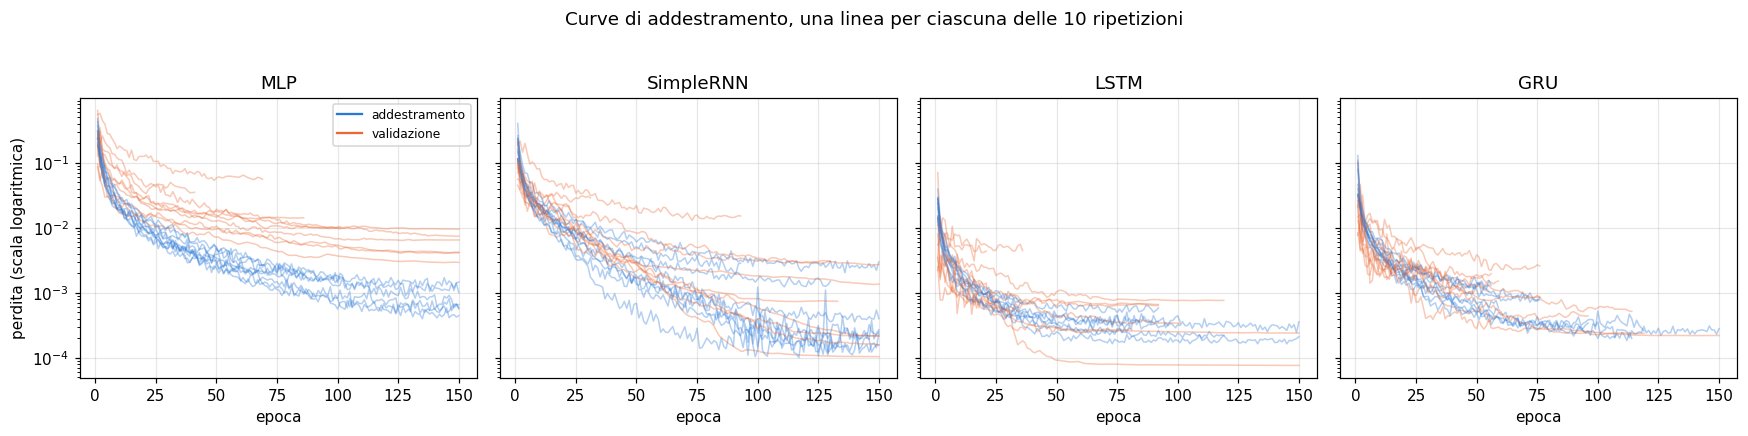

In [15]:
modelli = ["MLP", "SimpleRNN", "LSTM", "GRU"]
fig, axes = plt.subplots(1, len(modelli), figsize=(4 * len(modelli), 3.8), sharey=True)

for ax, nome in zip(axes, modelli):
    sottoinsieme = curve[curve.modello == nome]
    for seme, curva in sottoinsieme.groupby("seme"):
        ax.plot(curva.epoca, curva.loss, color="#2a78d6", alpha=0.35, lw=1)
        ax.plot(curva.epoca, curva.val_loss, color="#eb6834", alpha=0.35, lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("epoca")
    ax.set_title(nome)

axes[0].set_ylabel("perdita (scala logaritmica)")
axes[0].plot([], [], color="#2a78d6", label="addestramento")
axes[0].plot([], [], color="#eb6834", label="validazione")
axes[0].legend(fontsize=8)

fig.suptitle(f"Curve di addestramento, una linea per ciascuna delle "
             f"{N_RIPETIZIONI} ripetizioni", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_curve_addestramento.png", dpi=200, bbox_inches="tight")
plt.show()


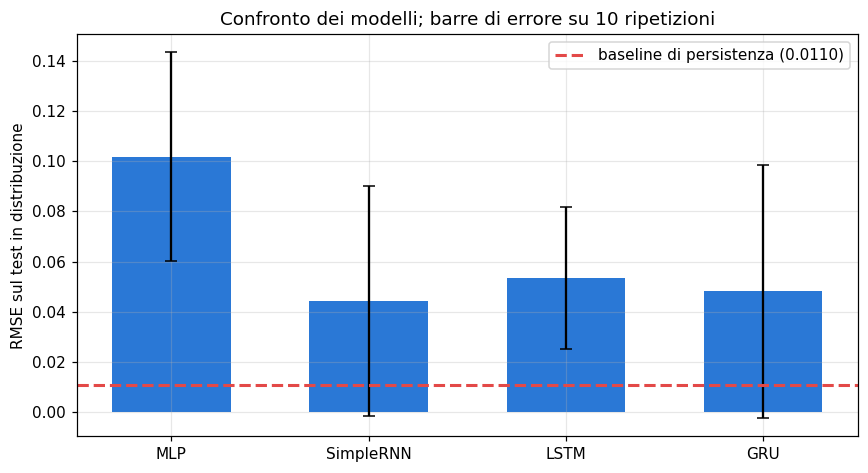

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.4))

posizioni = np.arange(len(modelli))
medie = [confronto_test[confronto_test.modello == m].RMSE_media.iloc[0] for m in modelli]
errori = [confronto_test[confronto_test.modello == m].RMSE_sd.iloc[0] for m in modelli]

ax.bar(posizioni, medie, 0.6, yerr=errori, capsize=4, color="#2a78d6")
# La baseline è la linea da superare: sotto è meglio.
ax.axhline(baseline_test.RMSE_media, color="#e34948", lw=2, ls="--",
           label=f"baseline di persistenza ({baseline_test.RMSE_media:.4f})")

ax.set_xticks(posizioni)
ax.set_xticklabels(modelli)
ax.set_ylabel("RMSE sul test in distribuzione")
ax.set_title(f"Confronto dei modelli; barre di errore su {N_RIPETIZIONI} ripetizioni")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_confronto_modelli.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Salvataggio delle previsioni

Vengono salvate le previsioni di tutti i modelli, accanto a quelle della baseline, così
che il notebook di valutazione possa riprenderle senza rieseguire l'addestramento.


In [17]:
righe = []
for nome_modello, previsioni in previsioni_per_modello.items():
    for insieme in INSIEMI:
        righe.append(pd.DataFrame({
            "modello": nome_modello,
            "insieme": insieme,
            "protocol_block": blocco[insieme],
            "battery_id": batteria[insieme],
            "target_cycle": ciclo[insieme],
            "soh_vero": y[insieme],
            "soh_previsto": previsioni[insieme],
            "soh_baseline": soh_ultimo[insieme],
        }))

for insieme in INSIEMI:
    righe.append(pd.DataFrame({
        "modello": "Baseline persistenza",
        "insieme": insieme,
        "protocol_block": blocco[insieme],
        "battery_id": batteria[insieme],
        "target_cycle": ciclo[insieme],
        "soh_vero": y[insieme],
        "soh_previsto": soh_ultimo[insieme],
        "soh_baseline": soh_ultimo[insieme],
    }))

previsioni_df = pd.concat(righe, ignore_index=True)
previsioni_df["errore"] = previsioni_df.soh_previsto - previsioni_df.soh_vero
previsioni_df.to_csv(PREDICTIONS_DIR / "03_predizioni.csv", index=False)

print(f"{len(previsioni_df)} previsioni salvate")
display(previsioni_df.head(5).round(5))


3980 previsioni salvate


,modello,insieme,protocol_block,battery_id,target_cycle,soh_vero,soh_previsto,soh_baseline,errore
0,MLP,train,B0005_p1,B0005,10,0.99415,0.97151,0.99415,-0.02264
1,MLP,train,B0005_p1,B0005,11,0.98848,0.97785,0.99415,-0.01062
2,MLP,train,B0005_p1,B0005,12,0.98823,1.00184,0.98848,0.01360
3,MLP,train,B0005_p1,B0005,13,0.98806,0.99194,0.98823,0.00387
4,MLP,train,B0005_p1,B0005,14,0.98216,0.94847,0.98806,-0.03369


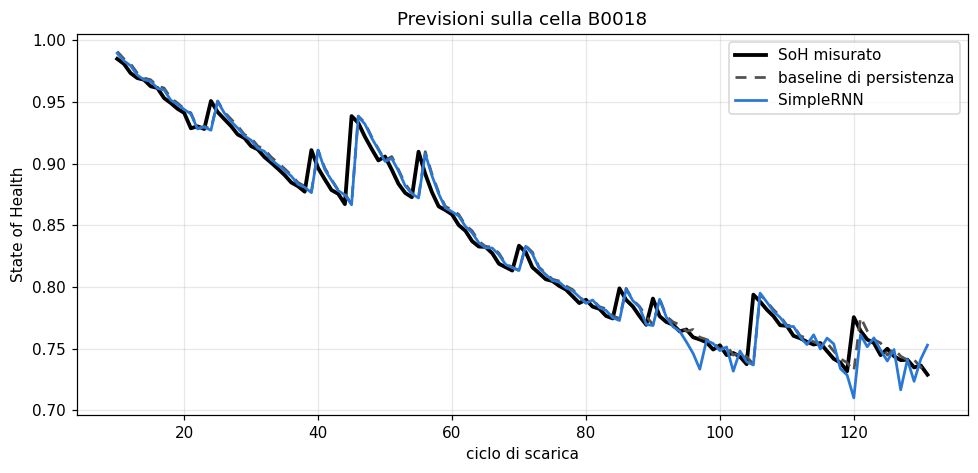

In [18]:
cella = sorted(set(batteria["test_id"]))[0]
traccia = (previsioni_df[(previsioni_df.insieme == "test_id")
                         & (previsioni_df.battery_id == cella)
                         & (previsioni_df.modello == migliore_neurale.modello)]
           .sort_values("target_cycle"))
baseline_traccia = (previsioni_df[(previsioni_df.insieme == "test_id")
                                  & (previsioni_df.battery_id == cella)
                                  & (previsioni_df.modello == "Baseline persistenza")]
                    .sort_values("target_cycle"))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(traccia.target_cycle, traccia.soh_vero, lw=2.5, color="black", label="SoH misurato")
ax.plot(baseline_traccia.target_cycle, baseline_traccia.soh_previsto, lw=1.8,
        ls=(0, (4, 3)), color="#52514e", label="baseline di persistenza")
ax.plot(traccia.target_cycle, traccia.soh_previsto, lw=1.8, color="#2a78d6",
        label=migliore_neurale.modello)

ax.set_xlabel("ciclo di scarica")
ax.set_ylabel("State of Health")
ax.set_title(f"Previsioni sulla cella {cella}")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_traiettoria_test.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Riepilogo


In [19]:
print("Esperimenti salvati:")
for cartella in sorted(EXPERIMENTS_DIR.glob(f"{DATA_ESECUZIONE}_*")):
    contenuto = ", ".join(sorted(p.name for p in cartella.iterdir()))
    print(f"  {cartella.name:30s} [{contenuto}]")

print("\nTabelle, figure e previsioni:")
for percorso in [TABLES_DIR / "03_metriche_per_ripetizione.csv",
                 TABLES_DIR / "03_confronto_modelli.csv",
                 TABLES_DIR / "03_confronto_appaiato.csv",
                 PREDICTIONS_DIR / "03_predizioni.csv",
                 FIGURES_DIR / "03_curve_addestramento.png",
                 FIGURES_DIR / "03_confronto_modelli.png",
                 FIGURES_DIR / "03_traiettoria_test.png"]:
    print("  ", percorso.relative_to(PROJECT_ROOT))

print("\nNotebook successivo: 04_data_scaling_experiment.ipynb")


Esperimenti salvati:
  20260830_1504_gru              [config.json, model.keras, training_log.csv]
  20260830_1504_lstm             [config.json, model.keras, training_log.csv]
  20260830_1504_mlp              [config.json, model.keras, training_log.csv]
  20260830_1504_simplernn        [config.json, model.keras, training_log.csv]

Tabelle, figure e previsioni:
   results/tables/03_metriche_per_ripetizione.csv
   results/tables/03_confronto_modelli.csv
   results/tables/03_confronto_appaiato.csv
   results/predictions/03_predizioni.csv
   results/figures/03_curve_addestramento.png
   results/figures/03_confronto_modelli.png
   results/figures/03_traiettoria_test.png

Notebook successivo: 04_data_scaling_experiment.ipynb
